#### Chihuahua vs Maffin classification

In [1]:
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import torch.optim as optim
from torchvision.models import ResNet18_Weights

from tqdm import tqdm
import random
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score
from PIL import Image


%matplotlib inline


In [2]:
plt.style.use('dark_background')

In [3]:
seed = 42
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)
random.seed(seed)
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

In [4]:
print("Torch:", torch.__version__)
print("Torch built with CUDA:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())
print("CUDA device count:", torch.cuda.device_count())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))


device   


Torch: 2.9.1+cu126
Torch built with CUDA: 12.6
CUDA available: True
CUDA device count: 1
GPU name: NVIDIA GeForce RTX 3050 Laptop GPU


device(type='cuda')

In [5]:
model = models.resnet18(weights=ResNet18_Weights.DEFAULT)

num_classes = 2
model.fc = nn.Linear(model.fc.in_features, num_classes) 

In [6]:
train_data_dir = 'dataset/train'
val_data_dir = 'dataset/val'

train_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
])

val_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
])

train_dataset = ImageFolder(train_data_dir, transform=train_transforms)
val_dataset = ImageFolder(val_data_dir, transform=val_transforms)

In [13]:
batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=True)

In [14]:
val_dataset[400][0].shape

torch.Size([3, 224, 224])

In [16]:
model(torch.randn(16, 3, 224, 224))

tensor([[ 0.0815,  0.4259],
        [ 0.3099, -0.1252],
        [-0.0383,  0.4610],
        [ 0.4351,  0.8219],
        [-0.5077,  0.4577],
        [ 0.1683,  0.7092],
        [-0.1066,  0.2143],
        [-0.1416,  0.2893],
        [ 0.1883,  0.5801],
        [ 0.0578,  0.3208],
        [-0.1327,  0.0960],
        [ 0.3764,  0.8325],
        [ 0.0731,  0.5403],
        [-0.9037,  0.9817],
        [-0.3569,  0.6842],
        [ 0.4440,  0.4761]], grad_fn=<AddmmBackward0>)

In [17]:
classes_list = train_dataset.classes
classes_list

['chihuahua', 'muffin']

In [18]:
train_class_counts = np.zeros(len(train_dataset.classes))
for _, label in train_dataset:
    train_class_counts[label] += 1

In [19]:
val_class_counts = np.zeros(len(val_dataset.classes))
for _, label in val_dataset:
    val_class_counts[label] += 1

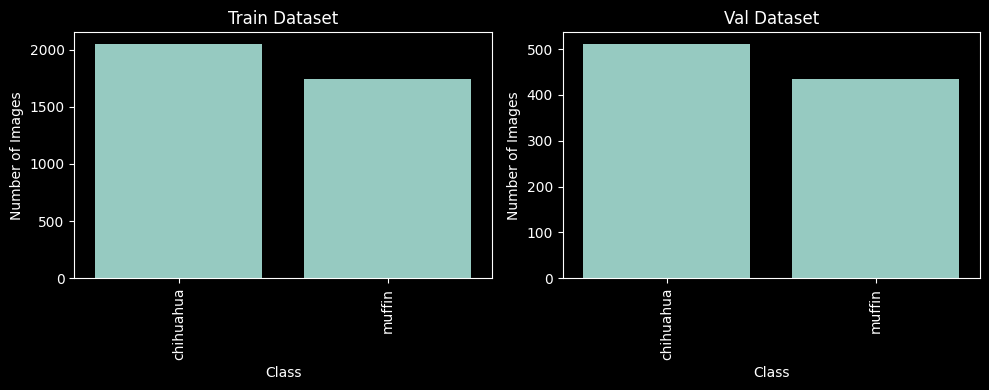

In [20]:
fig, ax = plt.subplots(1, 2, figsize=(10,4))

sns.barplot(x=train_dataset.classes, y = train_class_counts, ax=ax[0])
ax[0].set_title('Train Dataset')
ax[0].set_xlabel('Class')
ax[0].set_ylabel('Number of Images')
ax[0].tick_params(axis = 'x', rotation = 90)

sns.barplot(x=val_dataset.classes, y = val_class_counts, ax=ax[1])
ax[1].set_title('Val Dataset')
ax[1].set_xlabel('Class')
ax[1].set_ylabel('Number of Images')
ax[1].tick_params(axis = 'x', rotation = 90)

plt.tight_layout()
plt.show()

Images without normalization:


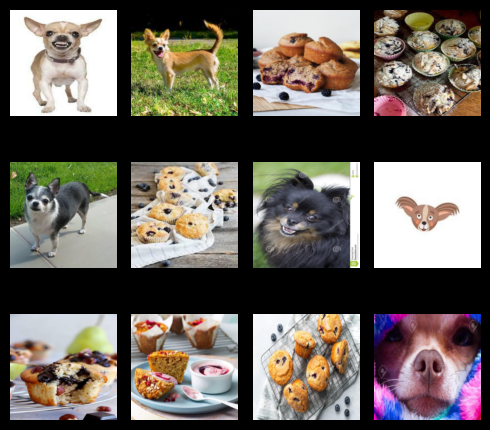

In [21]:
def show_images(images, denormalize=False, n_rows=3, n_cols=4):
    images = images.detach().cpu().numpy().transpose((0, 2, 3, 1))  # -> (B, H, W, C)

    if denormalize:
        mean = np.array([0.485, 0.456, 0.406])
        std  = np.array([0.229, 0.224, 0.225])
        images = images * std + mean
        images = np.clip(images, 0, 1)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5, 5))

    for i, ax in enumerate(axes.flat):
        if i >= len(images):
            ax.axis('off')
            continue
        ax.imshow(images[i])
        ax.axis('off')

    plt.tight_layout()
    plt.show()

images, labels = next(iter(train_loader))

print("Images without normalization:")
show_images(images, denormalize=False)


In [22]:
len(val_loader), len(train_loader)

(60, 237)

In [23]:
next(iter(train_loader))[1]

tensor([1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1])

In [24]:
model.eval()
model.to(device)
correct = 0
total = 0
with torch.no_grad():
    for images, labels in tqdm(val_loader):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        print(predicted)
        print(labels)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
val_accuracy = correct / total
val_accuracy

  3%|▎         | 2/60 [00:00<00:17,  3.24it/s]

tensor([0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0], device='cuda:0')
tensor([0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0], device='cuda:0')
tensor([0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1], device='cuda:0')
tensor([0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0], device='cuda:0')


  7%|▋         | 4/60 [00:00<00:09,  5.85it/s]

tensor([0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0], device='cuda:0')
tensor([1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0], device='cuda:0')
tensor([0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1], device='cuda:0')
tensor([0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1], device='cuda:0')


 10%|█         | 6/60 [00:01<00:08,  6.12it/s]

...

 97%|█████████▋| 58/60 [00:08<00:00,  5.63it/s]

tensor([0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0], device='cuda:0')
tensor([0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1], device='cuda:0')
tensor([1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0], device='cuda:0')
tensor([1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1], device='cuda:0')


100%|██████████| 60/60 [00:09<00:00,  6.50it/s]

tensor([1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0], device='cuda:0')
tensor([0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1], device='cuda:0')
tensor([0], device='cuda:0')
tensor([1], device='cuda:0')


0.6497354497354497

In [26]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=2e-4)


num_epochs = 10

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

best_val_accuracy = 0.0


for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in tqdm(train_loader):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_accuracy = correct / total
    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)

    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in tqdm(val_loader):
            images, labels = images. to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() 
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    val_loss /= len(val_loader)
    val_accuracy = correct / total
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    print(
    f'Epoch [{epoch+1}/{num_epochs}], '
    f'Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.4f}, '
    f'Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.4f}')

    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        torch.save(model.state_dict(), 'best_model.pth')
        print('Saved best model!')
    
    torch.save(model.state_dict(), 'last_model_pth')
    print()
print('Training and validation complete')




            

100%|██████████| 60/60 [00:09<00:00,  6.25it/s]


Epoch [1/10], Train Loss: 0.0355, Train Accuracy: 0.9900, Val Loss: 0.0594, Val Accuracy: 0.9778
Saved best model!



100%|██████████| 60/60 [00:09<00:00,  6.09it/s]


Epoch [2/10], Train Loss: 0.0132, Train Accuracy: 0.9960, Val Loss: 0.0625, Val Accuracy: 0.9799
Saved best model!



100%|██████████| 60/60 [00:09<00:00,  6.05it/s]


...

Epoch [8/10], Train Loss: 0.0092, Train Accuracy: 0.9971, Val Loss: 0.0654, Val Accuracy: 0.9778



100%|██████████| 60/60 [00:09<00:00,  6.04it/s]


Epoch [9/10], Train Loss: 0.0030, Train Accuracy: 0.9997, Val Loss: 0.0649, Val Accuracy: 0.9810



100%|██████████| 60/60 [00:11<00:00,  5.41it/s]


Epoch [10/10], Train Loss: 0.0006, Train Accuracy: 1.0000, Val Loss: 0.0772, Val Accuracy: 0.9746

Training and validation complete


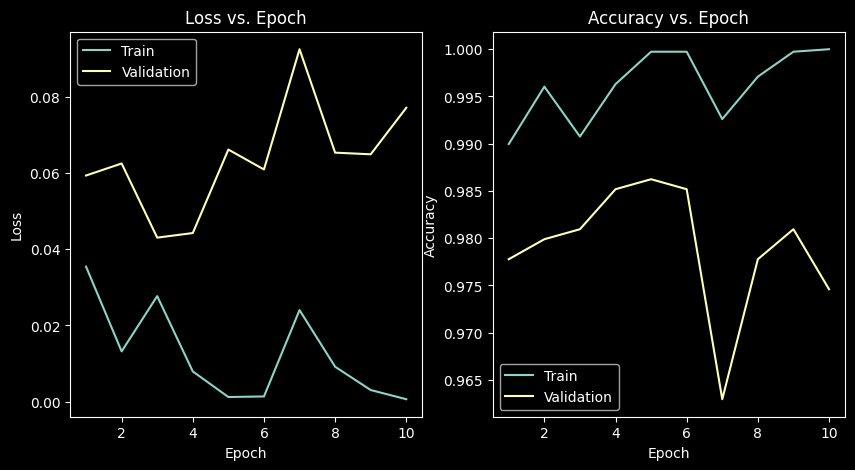

In [ ]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs + 1), train_losses, label='Train')
plt.plot(range(1, num_epochs + 1), val_losses, label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss vs. Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs + 1), train_accuracies, label='Train')
plt.plot(range(1, num_epochs + 1), val_accuracies, label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy vs. Epoch')
plt.legend()

plt.show()


In [28]:
def evaluate_model(model, dataloader):
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())

    cm = confusion_matrix(y_true, y_pred)
    report = classification_report(y_true, y_pred)
    accuracy = np.sum(np.diag(cm)) / np.sum(cm)
    weighted_f1 = f1_score(y_true, y_pred, average='weighted')

    return cm, report, accuracy, weighted_f1


def plot_confusion_matrix(cm, classes):
    with plt.style.context('default'):
        plt.figure(figsize=(5, 4))
        sns.set(font_scale=1.0)
        sns.heatmap(
            cm,
            annot=True,
            fmt='g',
            cmap='Blues',
            cbar=False,
            xticklabels=classes,
            yticklabels=classes
        )
        plt.xlabel('Predicted labels')
        plt.ylabel('True labels')
        plt.title('Confusion Matrix')
        plt.show()


Metrics for current model:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       511
           1       0.98      0.99      0.99       434

    accuracy                           0.99       945
   macro avg       0.99      0.99      0.99       945
weighted avg       0.99      0.99      0.99       945

Test Accuracy: 0.9862


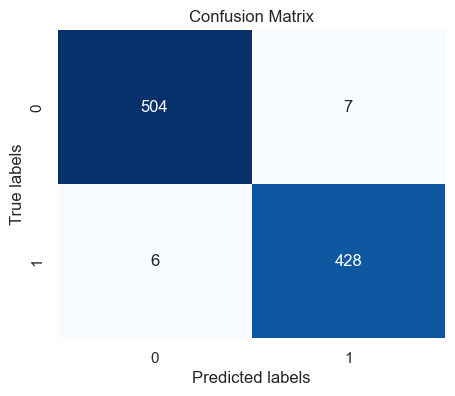

In [29]:
model.load_state_dict(torch.load('best_model.pth'))
model.to(device)

cm, report, accuracy_1, weighted_f1_1 = evaluate_model(model, val_loader)
print('Metrics for current model:')
print(report)
print(f'Test Accuracy: {accuracy_1:.4f}')
plot_confusion_matrix(cm, classes=list(range(2)))

augmentation 

In [34]:
model = models.resnet18(weights=ResNet18_Weights.DEFAULT)

num_classes = 2
model.fc = nn.Linear(model.fc.in_features, num_classes) 

In [35]:
train_data_dir = 'dataset/train'
val_data_dir = 'dataset/val'

train_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomRotation(10),
    transforms.CenterCrop(224),
    transforms.RandomHorizontalFlip(0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])

train_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])



train_dataset = ImageFolder(train_data_dir, transform=train_transforms)
val_dataset = ImageFolder(val_data_dir, transform=val_transforms)

batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

Images without normalization:


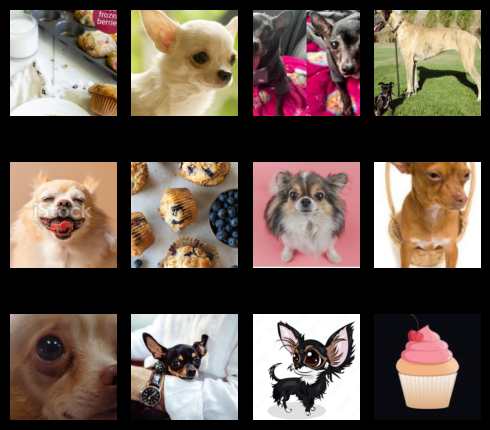

In [36]:
images, _ = next(iter(train_loader))
print('Images without normalization:')
show_images(images, denormalize=True)

In [37]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=2e-4)

num_epochs = 10

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []
best_val_accuracy = 0
model.to(device)

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(train_loader):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    train_loss = running_loss / len(train_loader)
    train_accuracy = correct / total
    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)


    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in tqdm(val_loader):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    val_loss /= len(val_loader)
    val_accuracy = correct / total
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    print(
    f'Epoch [{epoch+1}/{num_epochs}], '
    f'Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.4f}, '
    f'Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.4f}')

    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        torch.save(model.state_dict(), 'best_model.pth')
        print('Saved best model!')
    
    torch.save(model.state_dict(), 'last_model_pth')
    print()
print('Training and validation complete')
    

100%|██████████| 60/60 [00:11<00:00,  5.31it/s]


Epoch [1/10], Train Loss: 0.0745, Train Accuracy: 0.9747, Val Loss: 0.6585, Val Accuracy: 0.6360
Saved best model!



100%|██████████| 60/60 [00:09<00:00,  6.12it/s]


Epoch [2/10], Train Loss: 0.0396, Train Accuracy: 0.9865, Val Loss: 0.2649, Val Accuracy: 0.8963
Saved best model!



100%|██████████| 60/60 [00:09<00:00,  6.27it/s]


...

Epoch [8/10], Train Loss: 0.0085, Train Accuracy: 0.9974, Val Loss: 0.1814, Val Accuracy: 0.9302
Saved best model!



100%|██████████| 60/60 [00:10<00:00,  5.93it/s]


Epoch [9/10], Train Loss: 0.0071, Train Accuracy: 0.9982, Val Loss: 0.2307, Val Accuracy: 0.8836



100%|██████████| 60/60 [00:10<00:00,  5.74it/s]

Epoch [10/10], Train Loss: 0.0171, Train Accuracy: 0.9934, Val Loss: 0.1905, Val Accuracy: 0.9196

Training and validation complete


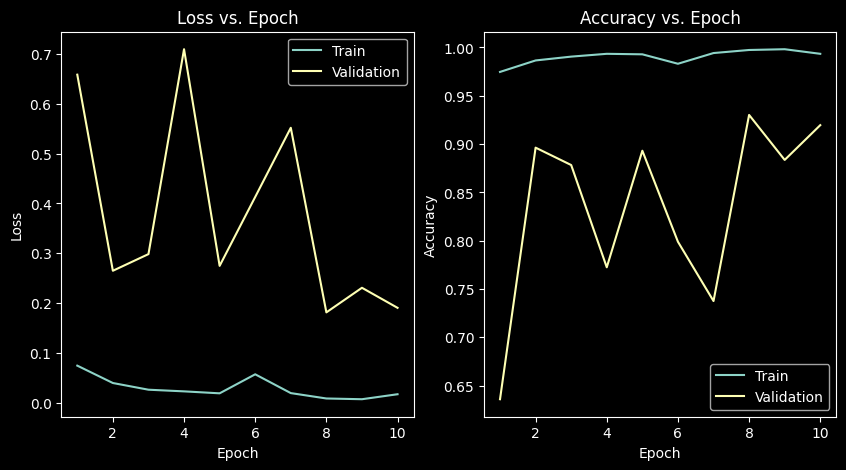

In [39]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs + 1), train_losses, label='Train')
plt.plot(range(1, num_epochs + 1), val_losses, label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss vs. Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs + 1), train_accuracies, label='Train')
plt.plot(range(1, num_epochs + 1), val_accuracies, label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy vs. Epoch')
plt.legend()

plt.show()


Metrics for current model:
              precision    recall  f1-score   support

           0       0.89      0.99      0.94       511
           1       0.99      0.85      0.92       434

    accuracy                           0.93       945
   macro avg       0.94      0.92      0.93       945
weighted avg       0.94      0.93      0.93       945

Test Accuracy: 0.9302


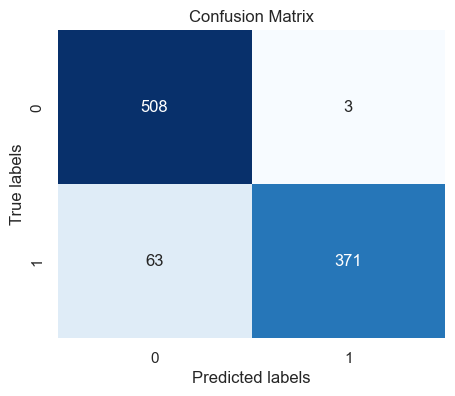

In [40]:
model.load_state_dict(torch.load('best_model.pth'))
model.to(device)


cm, report, accuracy_2, weighted_f1_2 = evaluate_model(model, val_loader)

print("Metrics for current model:")
print(report)
print(f'Test Accuracy: {accuracy_2:.4f}')

plot_confusion_matrix(cm, classes=list(range(2)))


In [43]:
model = models.resnet18()

num_classes = 2
model.fc = nn.Linear(model.fc.in_features, num_classes)


model.load_state_dict(torch.load('best_model.pth'))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

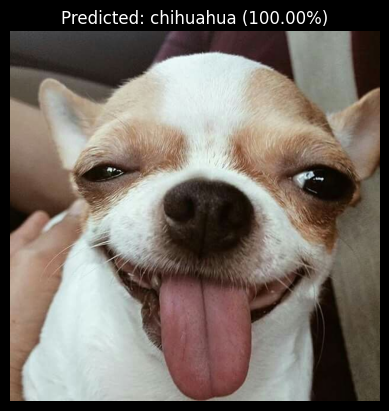

In [86]:
image_path = 'perevirka/img_04.jpg'
image = Image.open(image_path)
image_tensor = preprocess(image)
image_tensor = image_tensor.unsqueeze(0).to(device)

with torch.no_grad():
    output = model(image_tensor)

probabilities = torch.nn.functional.softmax(output[0], dim = 0).cpu()

top_prob, top_class = torch.topk(probabilities, 1)
top_prob = top_prob.item()
top_class = top_class.item()

class_names = ['chihuahua', 'muffin']
class_name = class_names[top_class]


plt.imshow(image)
plt.axis('off')
plt.title(f'Predicted: {class_name} ({top_prob*100:.2f}%)')
plt.show()

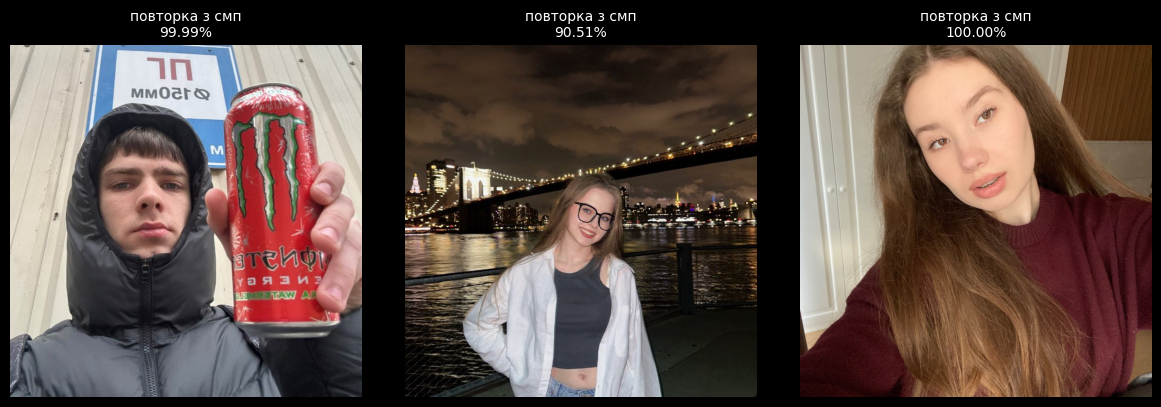

In [85]:
import glob
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


class_names = ['повторка з смп', '0']
image_paths = sorted(glob.glob('povtorka/*.jpg'))

images = []
original_images = []

for path in image_paths:
    img = Image.open(path).convert("RGB")
    original_images.append(img)
    tensor = preprocess(img)      
    images.append(tensor)

batch_tensor = torch.stack(images).to(device)

model.eval()
with torch.no_grad():
    outputs = model(batch_tensor)           

probs = torch.softmax(outputs, dim=1).cpu() 
top_probs, top_classes = torch.max(probs, dim=1)


num_images = len(image_paths)
fig, axes = plt.subplots(1, num_images, figsize=(4 * num_images, 4))


if num_images == 1:
    axes = [axes]

for ax, path, img, prob, cls_idx in zip(axes, image_paths, original_images, top_probs, top_classes):
    class_name = class_names[cls_idx.item()]
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f'{class_name}\n{prob.item()*100:.2f}%', fontsize=10)

plt.tight_layout()
plt.show()
